#AQFT - comparativo entre AQFT e valor esperado QFT

In [1]:
#!/usr/bin/env -S python3 -u 
"""
usage:aqft.ipynb

options:
    None

description:
    This notebook contains code to test the precision difference between AQFT and QFT. 

"""
__author__      = 'Eduardo Marsola do Nascimento'
__copyright__   = 'Copyright 2026-04-12'
__credits__     = ''
__license__     = 'MIT'
__version__     = '1.00'
__maintainer__  = ''
__email__       = ''
__status__      = 'Production'
__printdebug__  = False


"""
to prepare the environment
1. create a virtual environment: 
    python -m venv ./venv
2. upgrade pip: 
    python -m pip install --upgrade pip
3. install libraries:
## installing NumPy and MatPlotLib
    pip install numpy
    pip install matplotlib
## installing PyCryptodome
    pip install pycryptodome
## installing Qiskit
    pip install qiskit
    pip install qiskit-aer
    pip install qiskit-ibm-runtime
    pip install pylatexenc
"""

!pip install numpy
!pip install matplotlib
!pip install pycryptodome
!pip install qiskit
!pip install qiskit-aer
!pip install qiskit-ibm-runtime
!pip install pylatexenc
!pip install mpmath


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:

## carrega bibliotecas
import qiskit
import Crypto
import decimal

from decimal import *

from datetime import datetime
from Crypto.Util import number
from Crypto.Random import random
import matplotlib.pyplot as plt
import numpy as np
import mpmath
from mpmath import mp
import math

from fractions import Fraction

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


print(f'qiskit.__version__={qiskit.__version__}')
print(f'numpy.__version__={np.__version__}')
print(f'decimal.__version__={decimal.__version__}')
print(f'Crypto.__version__={Crypto.__version__}')
print(f'mpmath.__version__={mpmath.__version__}')

mp.dps=100

qiskit.__version__=2.3.1
numpy.__version__=2.3.4
decimal.__version__=1.70
Crypto.__version__=3.23.0
mpmath.__version__=1.4.1


# gera a AQFT - gerado com auxilio do Anthropic Claude

In [3]:
#### aplica o shor para fatorar um número composto N usando a base a
def return_order(N: int, a: int) -> int:
    r = 1
    power = a % N
    while power != 1 and r <= N:
        power = (power * a) % N
        r += 1
    return r

def shors_algorithm(N: int ) -> int:
    """Implementação simplificada do algoritmo de Shor para fatoração de N usando a base a."""
    MAX_TENTATIVAS = N
    tentativas = 0

    while tentativas < MAX_TENTATIVAS:
        tentativas += 1
        # Passo 1: Seleciona um a aleatório entre 2 e N-1 e coprimo com N
        a = random.randint(2, N - 1)
        print(f"Tentativa {tentativas}: a = {a}")
        if math.gcd(a, N) != 1:
            print(f"{a} não é coprimo com {N}. Encontrado fator trivial: {math.gcd(a, N)}")
            continue
        
        # Passo 2: Encontrar a ordem r de a módulo N
        r = return_order(N, a)
        if r % 2 != 0:
            print(f"A ordem r = {r} é ímpar. Tentando outro valor de a.")
    
        ar_half = pow(a, r // 2, N)
        if ar_half == N - 1:
            print(f"a^(r/2) é congruente a -1 mod N. Tente outro valor de a.")
            continue
        
        # Passo 4: Calcular os fatores candidatos
        factor1 = math.gcd(ar_half - 1, N)
        factor2 = math.gcd(ar_half + 1, N)
        
        # Verificar se os fatores são válidos
        if factor1 in [1, N] or factor2 in [1, N]:
            print(f"Fatores triviais encontrados. Tente outro valor de a.")
            continue
        
        return factor1, factor2, a, r
    print(f"Falha ao encontrar fatores não triviais após {MAX_TENTATIVAS} tentativas.")
    

def find_shor_example(nBits=16):
    # Gerar um número composto N para fatorar
    p = number.getPrime(nBits // 2)
    q = number.getPrime(nBits // 2 + nBits % 2)
    N = p * q
    print(f"N = {N} (fatores: {p}, {q})")
    
    # Executar o algoritmo de Shor
    factor1, factor2, a, r = shors_algorithm(N)
    if factor1 is not None:
        print(f"N={N}, a={a}, r={r}, p={factor1}, q={factor2}")  
    else:
        print("Nenhum fator encontrado.")

find_shor_example(nBits=20)
# exemplos
# 16 bits
# N=29737, a=9094, r=14690, p=131, q=227
# N=34717, a=29699, r=8584, p=149, q=233
# N=27221, a=4888, r=13446, p=163, q=167
# N=60491, a=44565, r=120, p=251, q=241
# N=32437, a=23138, r=594, p=163, q=199
# N=21509, a=15983, r=5304, p=157, q=137
# N=26123, a=10452, r=516, p=151, q=173
# N=45901, a=12354, r=11368, p=197, q=233
# N=33389, a=28255, r=8256, p=173, q=193
# N=41693, a=10464, r=3440, p=173, q=241
# 
# 5 bits
# N=35, a=32, r=12, p=7, q=5
# N=21, a=11, r=6, p=7, q=3
# N=15, a=8, r=4, p=3, q=5
#
# 20 bits
# N=525323, a=235635, r=130962, p=599, q=877

N = 706777 (fatores: 719, 983)
Tentativa 1: a = 85723
N=706777, a=85723, r=352538, p=719, q=983


#Functions with QISKIT

Exemplo: N=21, a=11, r=6, p=7, q=3, L=5, phi=2*pi*0.1666666666666667
Circuito AQFT† - L=5, m=5:
probabilities:
00000: 0.1874999999999996
00001: 0.0594563748140453
00010: 0.0024711559589238
00011: 0.0060258844687871
00100: 0.0030509710293068
00101: 0.0016231897966129
00110: 0.0046214853902040
00111: 0.0002548652318969
01000: 0.0104166666666668
01001: 0.0008920661882395
01010: 0.1168040797086754
01011: 0.1673295537954325
01100: 0.0177823623040266
01101: 0.0089469370380450
01110: 0.0011032789421972
01111: 0.0054711286669391
10000: 0.0000000000000000
10001: 0.0054711286669391
10010: 0.0011032789421973
10011: 0.0089469370380452
10100: 0.0177823623040265
10101: 0.1673295537954347
10110: 0.1168040797086744
10111: 0.0008920661882395
11000: 0.0104166666666666
11001: 0.0002548652318968
11010: 0.0046214853902039
11011: 0.0016231897966131
11100: 0.0030509710293068
11101: 0.0060258844687873
11110: 0.0024711559589238
11111: 0.0594563748140459
total probability: 0.9999999999999991 

Circuito AQFT† - 

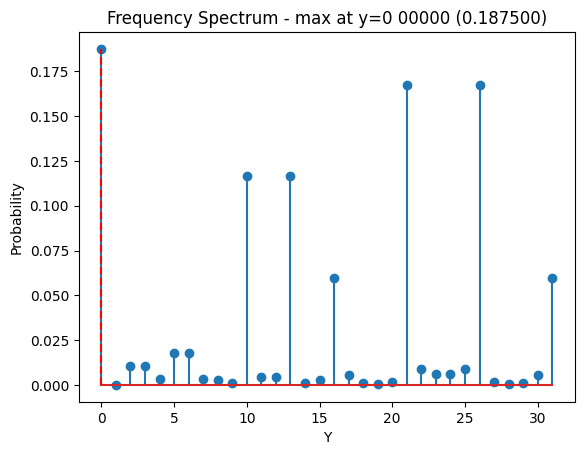

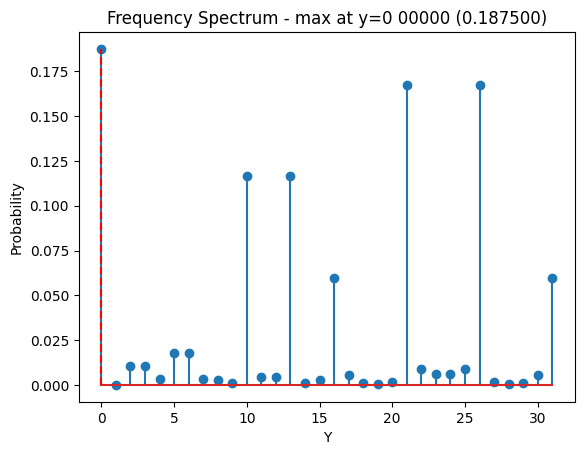

In [4]:
def aqft_dagger(L: int, m: int) -> QuantumCircuit:
    """
    AQFT inversa truncada em L qubits.
    Mantém apenas rotações controladas até distância m.
    Para m >= L, coincide com a IQFT usual (sem swaps explícitos, mas com
    correção de bit-reversal na leitura).
    ### Original function using QISKIT
    """
    qc = QuantumCircuit(L, name=f"AQFT†(L={L},m={m})")
    # Implementação padrão da IQFT sem swaps finais
    for j in range(L):
        # rotações controladas truncadas
        start_k = max(0, j - m + 1)
        for k in range(start_k, j):
            angle = -np.pi / (2 ** (j - k))
            qc.cp(angle, k, j)
        qc.h(j)
    return qc

def normalize(psi):
    norm = mp.sqrt(sum(abs(a)**2 for a in psi))
    return [a / norm for a in psi]

def define_initial_state_for_order(r: int, L: int ) -> Statevector:
    """
    Estado do registrador de fase após phase kickback e antes da IQFT/AQFT:
    (1/sqrt(2^L)) sum_x exp(2πi phi x) |x>
    """
    M = 2 ** L
    amps = np.zeros(M, dtype=complex)
    for i in range(r):
        phi = i/r
        amps += np.exp(2j * np.pi * phi * np.arange(M)) / np.sqrt(M)
    amps = normalize(amps)
    #amps /= r  # Normaliza o vetor de estado
    #phi = 1/r
    #amps += np.exp(2j * np.pi * phi * np.arange(M)) / np.sqrt(M)
    return Statevector(amps)

def define_initial_state_for_phase_estimation(phi: float, L: int ) -> Statevector:
    """
    Estado do registrador de fase após phase kickback e antes da IQFT/AQFT:
    (1/sqrt(2^L)) sum_x exp(2πi phi x) |x>
    """
    M = 2 ** L
    amps = np.exp(2j * np.pi * phi * np.arange(M)) / np.sqrt(M)
    return Statevector(amps)

def bit_reverse(x: int, nbits: int) -> int:
    out = 0
    for _ in range(nbits):
        out = (out << 1) | (x & 1)
        x >>= 1
    return out

def aqft_example(N, a, r, p, q):
    L = int(math.log2(N))+1
    phi = ((1)/r)
        
    # gera AQFT† para diferentes m
    print(f"Exemplo: N={N}, a={a}, r={r}, p={p}, q={q}, L={L}, phi=2*pi*{phi:.16f}")
    for m in [L,5]:
        qc = aqft_dagger(L, m)
        print (f'Circuito AQFT† - L={L}, m={m}:')
        fig = qc.draw('mpl')
        fig.suptitle(f'AQFT† - L={L}, m={m}', fontsize=16)
        fig.savefig(f'img/aqft_dagger_L_{L}_m_{m}.png')

        #sv_initial = define_initial_state_for_phase_estimation(phi, L)
        sv_initial = define_initial_state_for_order(r, L)
        #print(f'{sv_initial}')

        sv_final = sv_initial.evolve(qc)
        #print(f'{sv_final}')

        probs = sv_final.probabilities()
        print("probabilities:")
        for i, p in enumerate(probs):
            #print(i, p)
            print(f'{i:0{L}b}: {p:.16f}')
        print(f'total probability: {sum(probs):.16f} ')
        print(f'')


        reordered_probs = np.zeros_like(probs)
        for y, p in enumerate(probs):
            reordered_probs[bit_reverse(y, L)] = p
    
        ys = np.arange(len(reordered_probs))
        peak_y = np.argmax(reordered_probs)
        peak_value = np.max(reordered_probs)

        plt.figure()
        plt.stem(ys, reordered_probs)
        plt.xlabel("Y")
        plt.ylabel("Probability")
        plt.title(f"Frequency Spectrum - max at y={peak_y} {peak_y:0{L}b} ({peak_value:.6f})")
        plt.vlines(peak_y, 0, peak_value,colors='r', linestyles='dashed', label='Peak')
        plt.savefig(f'img/probability_qiskit_L_{L}_m_{m}.png')
        #plt.show()
        
    return

#aqft_example(N=15, a=8, r=4, p=3, q=5)
aqft_example(N=21, a=11, r=6, p=7, q=3)
#aqft_example(N=29737, a=9094, r=14690, p=131, q=227)

#functions without QISKIT

In [ ]:
def normalize(psi):
    norm = mp.sqrt(sum(abs(a)**2 for a in psi))
    return [a / norm for a in psi]


def apply_hadamard(psi, qubit, n):
    """Apply H to qubit"""
    new_psi = psi.copy()
    N = len(psi)

    for i in range(N):
        if ((i >> qubit) & 1) == 0:
            j = i | (1 << qubit)

            a = psi[i]
            b = psi[j]

            new_psi[i] = (a + b) / mp.sqrt(2)
            new_psi[j] = (a - b) / mp.sqrt(2)

    return new_psi

def apply_cp(psi, control, target, theta):
    """Apply controlled phase"""
    new_psi = psi.copy()
    N = len(psi)

    for i in range(N):
        if ((i >> control) & 1) and ((i >> target) & 1):
            new_psi[i] *= mp.exp(1j * theta)

    return new_psi

# -----------------------------------
# AQFT dagger (your exact structure)
# -----------------------------------
def aqft_dagger_state(psi, L, m):
    psi = psi.copy()

    for j in range(L):
        start_k = max(0, j - m + 1)
        # controlled phase rotations
        for k in range(start_k, j):
            angle = -mp.pi / (2 ** (j - k))
            psi = apply_cp(psi, k, j, angle)

        # Hadamard
        psi = apply_hadamard(psi, j, L)

    return psi

def iqft_state(psi, L):
    return aqft_dagger_state(psi, L, m=L)



# -----------------------------------
# Probabilities
# -----------------------------------
def probabilities(psi):
    return [abs(a)**2 for a in psi]


def define_initial_state_for_order(r: int, L: int ):
    """
    Estado do registrador de fase após phase kickback e antes da IQFT/AQFT:
    (1/sqrt(2^L)) sum_x exp(2πi phi x) |x>
    """
    v_exp = np.vectorize(mp.exp)
    M = 2 ** L
    amps = np.array([mp.mpc(0)]*M)
    for i in range(r):
        phi = mp.mpc(i)/mp.mpc(r)
        amps += v_exp(2j * mp.pi * phi * np.arange(M)) / mp.sqrt(M)
    #amps /= r  # Normaliza o vetor de estado
    return amps

def bit_reverse(x: int, nbits: int) -> int:
    out = 0
    for _ in range(nbits):
        out = (out << 1) | (x & 1)
        x >>= 1
    return out

def aqft_example(N, a, r, p, q):
    L = int(mp.log(N, 2)) + 1
    phi = (1/r)
    M = 2 ** L

    print(f"Exemplo: N={N}, a={a}, r={r}, p={p}, q={q}, L={L}, phi=2*pi*{phi:.16f}")

    # Example: |011>
    #psi = [mp.mpc(0) for _ in range(M)]
    #psi[3] = mp.mpc(1)
    psi = define_initial_state_for_order(r, L)
    psi = normalize(psi)

    # IQFT
    psi_iqft = iqft_state(psi, L)
    prob_iqft = probabilities(psi_iqft)
    print("IQFT probabilities:")
    for i, p in enumerate(prob_iqft):
        print(f'{i:0{L}b}: {float(p):.16f}')
    print(f'total probability: {float(sum(prob_iqft)):.16f} ')
    print(f'')

    # AQFT with truncation m=5
    psi_aqft = aqft_dagger_state(psi, L, m=5)
    prob_aqft = probabilities(psi_aqft)
    print("\nAQFT probabilities (m=5):")
    for i, p in enumerate(prob_aqft):
        print(f'{i:0{L}b}: {float(p):.16f}')
    print(f'total probability: {float(sum(prob_aqft)):.16f} ')
    print(f'')

    error = sum(mp.fabs(prob_iqft[i] - prob_aqft[i]) for i in range(len(prob_iqft)))
    print(f"\nTotal error (L1 norm): {float(error):.16f}")
    print(f'')

    i=0
    for probs in [prob_iqft, prob_aqft]:
        reordered_probs = np.zeros_like(probs)
        for y, p in enumerate(probs):
            reordered_probs[bit_reverse(y, L)] = p
    
        ys = np.arange(len(reordered_probs))
        peak_y = np.argmax(reordered_probs)
        peak_value = np.max(reordered_probs)

        plt.figure()
        plt.stem(ys, reordered_probs)
        plt.xlabel("Y")
        plt.ylabel("Probability")
        plt.title(f"Frequency Spectrum - max at y={peak_y} {peak_y:0{L}b} ({float(peak_value):.6f})")
        plt.vlines(peak_y, 0, peak_value,colors='r', linestyles='dashed', label='Peak')
        plt.savefig(f'img/probability_mpmath_{i}_L_{L}.png')
        #plt.show()
        i+=1
    return

# -----------------------------------
# Example
# -----------------------------------
if __name__ == "__main__":

    #aqft_example(N=15, a=8, r=4, p=3, q=5)
    aqft_example(N=21, a=11, r=6, p=7, q=3)
    #aqft_example(N=29737, a=9094, r=14690, p=131, q=227)



Exemplo: N=29737, a=9094, r=14690, p=131, q=227, L=15, phi=2*pi*0.0000680735194010
